# HPC Discoveries Analysis

Analysis of free line arrangements discovered by the RL agent on the HPC.

In [8]:
import json
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime

sys.path.insert(0, '.')
from arrangement import LineArrangement
all_exponent_types = LineArrangement.all_exponent_types

# Load data
with open('discoveries_28Apr.json') as f:
    raw = json.load(f)

df = pd.DataFrame(raw['arrangements'])

# Parse exponents
df['exp_tuple'] = df['exponents'].apply(tuple)
df['d2'] = df['exponents'].apply(lambda x: x[1])
df['d3'] = df['exponents'].apply(lambda x: x[2])
df['exp_type'] = list(zip(df['d2'], df['d3']))
df['n_lines'] = df['lines'].apply(len)
df['ts'] = pd.to_datetime(df['timestamp'])

# Range of n we want to analyze (full target range, not just what's in df)
all_ns = list(range(6, 21))

print(f"Total discoveries: {len(df):,}")
print(f"Unique n values in data: {sorted(df['n'].unique())}")
print(f"Analyzing n range: {all_ns[0]}..{all_ns[-1]}")
print(f"Date range: {df['ts'].min()} to {df['ts'].max()}")
df.head()

Total discoveries: 120,027
Unique n values in data: [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Analyzing n range: 6..20
Date range: 2026-03-31 13:18:30.685521+00:00 to 2026-04-22 07:22:16.903453+00:00


,n,exponents,b2,max_mult,mult_profile,n_pts,lines,source,target_exponents,timestamp,exp_tuple,d2,d3,exp_type,n_lines,ts
0,6,"[1, 2, 3]",11,4.0,"[4, 3, 2, 2, 2, 2, 2, 2]",8.0,"[(0x+1y+-4z=0), (1x+1/4y+-5/4z=0), (0x+1y+-3/5...",train,"[2, 3]",2026-03-31T13:18:30.685521+00:00,"(1, 2, 3)",2,3,"(2, 3)",6,2026-03-31 13:18:30.685521+00:00
1,7,"[1, 3, 3]",15,4.0,"[4, 3, 3, 3, 2, 2, 2, 2, 2, 2]",10.0,"[(1x+1y+3z=0), (1x+-3/4y+1z=0), (1x+0y+4/3z=0)...",train,"[1, 5]",2026-03-31T13:19:06.200298+00:00,"(1, 3, 3)",3,3,"(3, 3)",7,2026-03-31 13:19:06.200298+00:00
2,8,"[1, 3, 4]",19,4.0,"[4, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2]",12.0,"[(1x+-2y+-1z=0), (1x+-1y+-1z=0), (1x+0y+3/4z=0...",train,"[1, 6]",2026-03-31T13:32:39.507943+00:00,"(1, 3, 4)",3,4,"(3, 4)",8,2026-03-31 13:32:39.507943+00:00
3,6,"[1, 2, 3]",11,3.0,"[3, 3, 3, 3, 2, 2, 2]",7.0,"[(1x+3/2y+2z=0), (1x+-1/3y+0z=0), (1x+-2/5y+2/...",train,"[1, 4]",2026-03-31T13:32:49.097075+00:00,"(1, 2, 3)",2,3,"(2, 3)",6,2026-03-31 13:32:49.097075+00:00
4,6,"[1, 2, 3]",11,4.0,"[4, 3, 2, 2, 2, 2, 2, 2]",8.0,"[(0x+1y+-5/3z=0), (1x+5y+-1z=0), (1x+5y+-2z=0)...",train,"[1, 4]",2026-03-31T13:32:56.395728+00:00,"(1, 2, 3)",2,3,"(2, 3)",6,2026-03-31 13:32:56.395728+00:00


## Overview: Discoveries per n

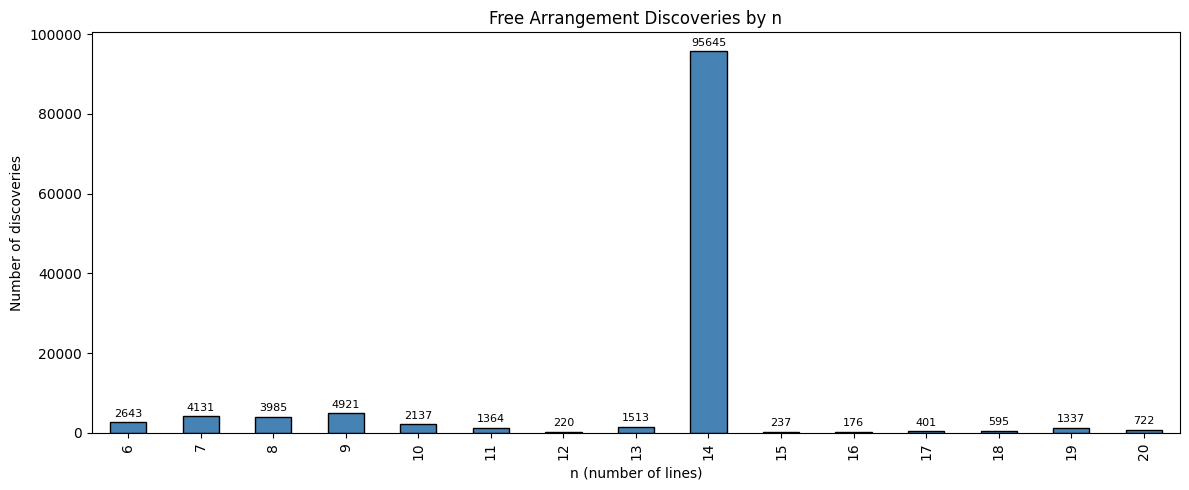

n
6      2643
7      4131
8      3985
9      4921
10     2137
11     1364
12      220
13     1513
14    95645
15      237
16      176
17      401
18      595
19     1337
20      722


In [9]:
counts_by_n = df['n'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
counts_by_n.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('n (number of lines)')
ax.set_ylabel('Number of discoveries')
ax.set_title('Free Arrangement Discoveries by n')
for i, (n, count) in enumerate(counts_by_n.items()):
    ax.text(i, count + max(counts_by_n) * 0.01, str(count), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print(counts_by_n.to_string())

## Exponent Diversity Heatmap

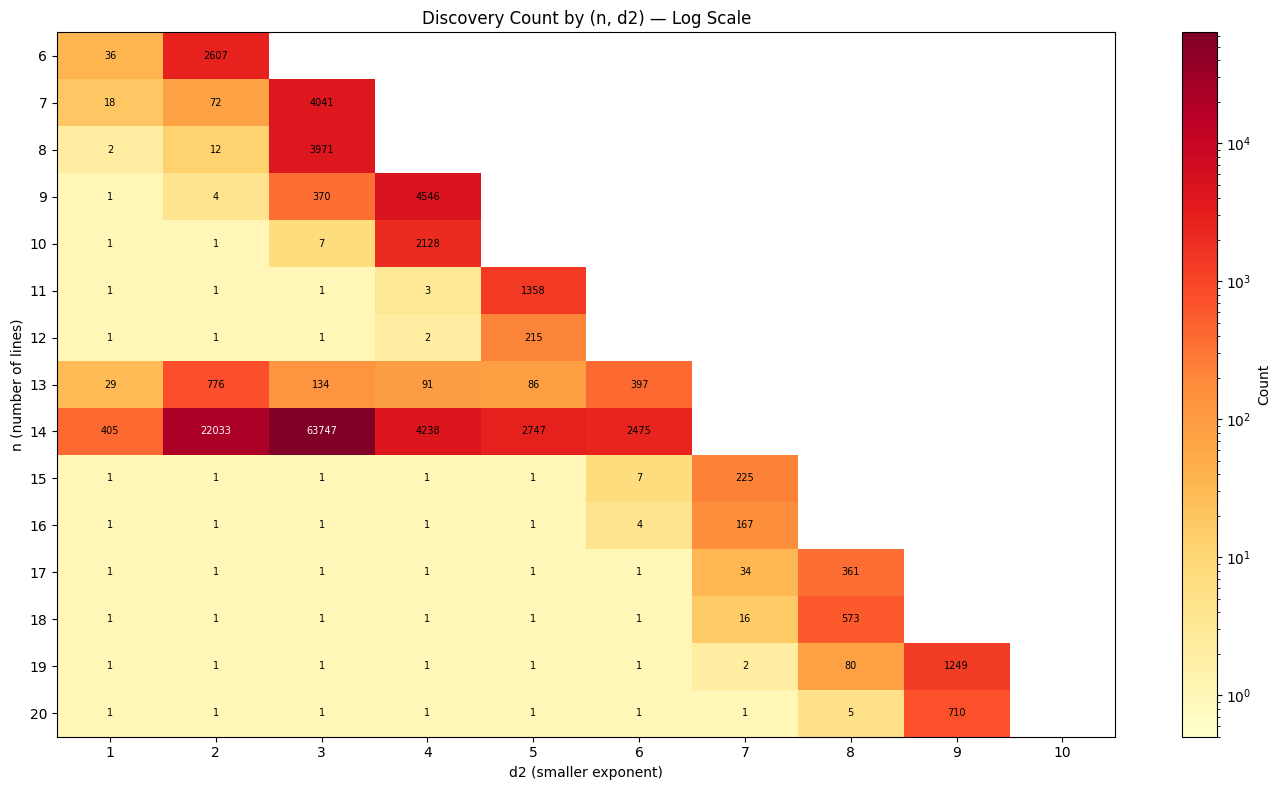

In [10]:
# Build matrix: rows=n, columns=d2
heat_data = df.groupby(['n', 'd2']).size().unstack(fill_value=0)

# Fill in all possible d2 values
max_d2 = max(df['d2'].max(), max(n // 2 for n in all_ns))
for d2 in range(1, max_d2 + 1):
    if d2 not in heat_data.columns:
        heat_data[d2] = 0
heat_data = heat_data.reindex(sorted(heat_data.columns), axis=1)
heat_data = heat_data.sort_index()

# Mask impossible cells
mask = np.zeros_like(heat_data.values, dtype=bool)
for i, n in enumerate(heat_data.index):
    valid_d2s = {d2 for d2, d3 in all_exponent_types(n)}
    for j, d2 in enumerate(heat_data.columns):
        if d2 not in valid_d2s:
            mask[i, j] = True

fig, ax = plt.subplots(figsize=(14, 8))
data_plot = heat_data.values.astype(float)
data_plot[mask] = np.nan

im = ax.imshow(data_plot, aspect='auto', cmap='YlOrRd',
               norm=mcolors.LogNorm(vmin=0.5, vmax=max(1, np.nanmax(data_plot))))

ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns)
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index)
ax.set_xlabel('d2 (smaller exponent)')
ax.set_ylabel('n (number of lines)')
ax.set_title('Discovery Count by (n, d2) — Log Scale')

# Annotate cells
for i in range(data_plot.shape[0]):
    for j in range(data_plot.shape[1]):
        if not mask[i, j]:
            val = int(heat_data.values[i, j])
            color = 'white' if val > np.nanmax(data_plot) * 0.3 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()

## Multiplicity Analysis

/var/folders/vx/ftrg36ns3qg15t94j080x7ww0000gn/T/ipykernel_54079/1860426368.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(box_data, labels=all_ns, patch_artist=True)


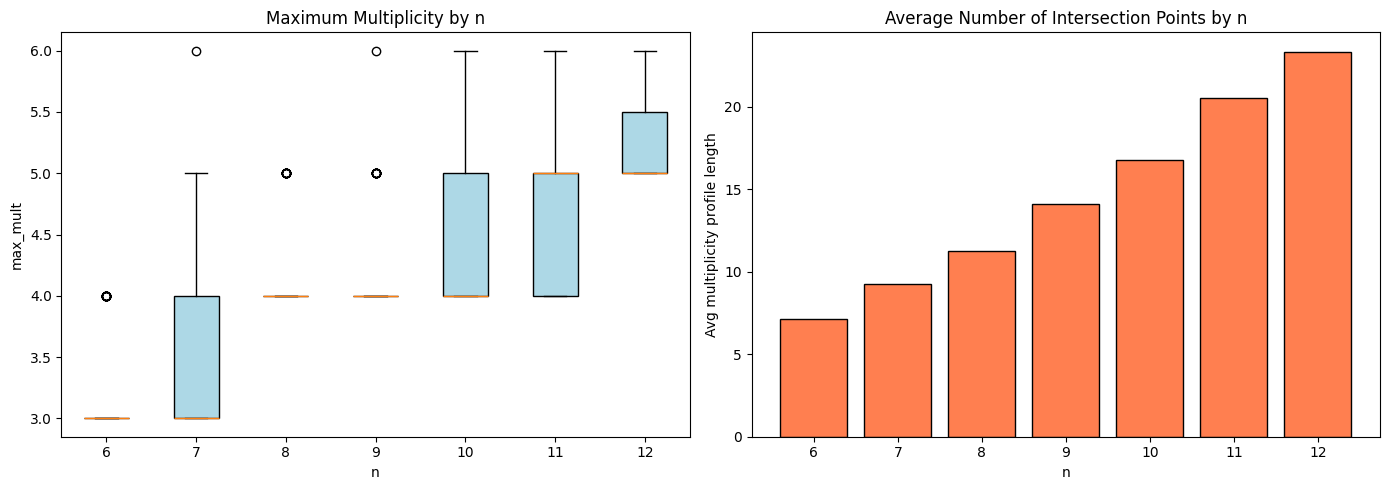

    count  max_mult_mean  max_mult_max  avg_n_pts
n                                                
6     126           3.14             4       7.14
7     175           3.30             6       9.26
8     148           4.09             5      11.28
9     142           4.09             6      14.08
10     52           4.31             6      16.79
11     46           4.65             6      20.52
12      3           5.33             6      23.33


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of max_mult by n
box_data = [df[df['n'] == n]['max_mult'].values for n in all_ns]
bp = axes[0].boxplot(box_data, labels=all_ns, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[0].set_xlabel('n')
axes[0].set_ylabel('max_mult')
axes[0].set_title('Maximum Multiplicity by n')

# Average mult profile length by n
df['profile_len'] = df['mult_profile'].apply(len)
avg_profile = df.groupby('n')['profile_len'].mean()
axes[1].bar(avg_profile.index, avg_profile.values, color='coral', edgecolor='black')
axes[1].set_xlabel('n')
axes[1].set_ylabel('Avg multiplicity profile length')
axes[1].set_title('Average Number of Intersection Points by n')

plt.tight_layout()
plt.show()

# Summary table
mult_stats = df.groupby('n').agg(
    count=('max_mult', 'size'),
    max_mult_mean=('max_mult', 'mean'),
    max_mult_max=('max_mult', 'max'),
    avg_n_pts=('n_pts', 'mean'),
).round(2)
print(mult_stats.to_string())

## b2 Distribution

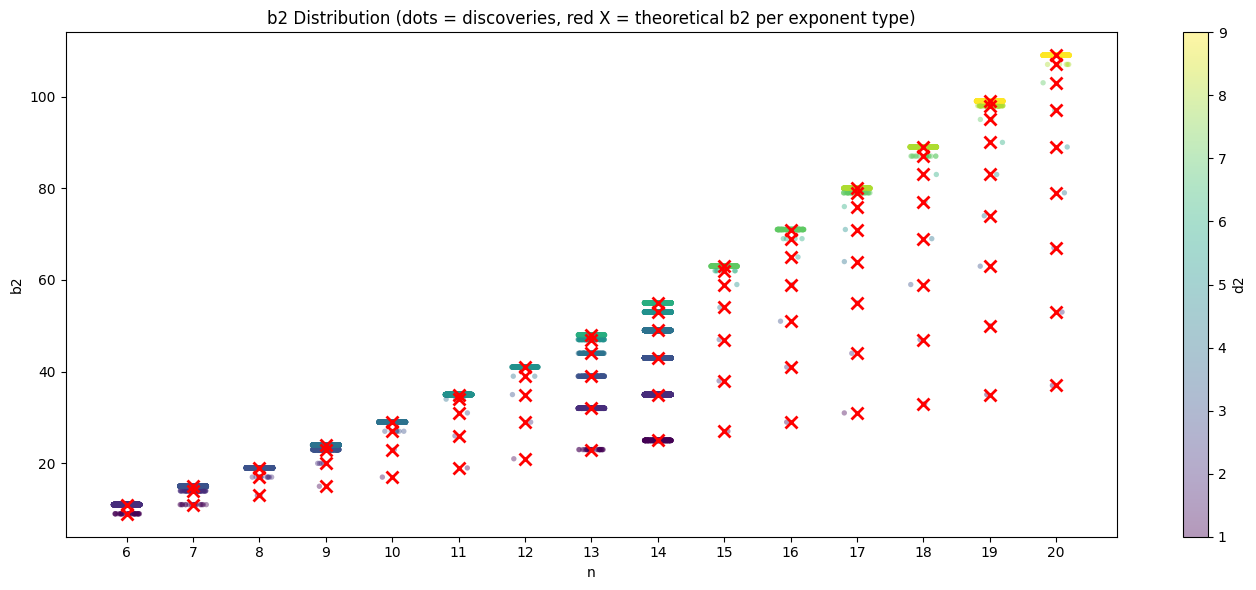

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

# Scatter: actual b2 by n, colored by d2
scatter = ax.scatter(df['n'] + np.random.uniform(-0.2, 0.2, len(df)),
                     df['b2'], c=df['d2'], cmap='viridis',
                     alpha=0.4, s=15, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='d2')

# Overlay theoretical b2 for each exponent type
for n in all_ns:
    for d2, d3 in all_exponent_types(n):
        target_b2 = (n - 1) + d2 * d3
        ax.plot(n, target_b2, 'rx', markersize=8, markeredgewidth=2)

ax.set_xlabel('n')
ax.set_ylabel('b2')
ax.set_title('b2 Distribution (dots = discoveries, red X = theoretical b2 per exponent type)')
ax.set_xticks(all_ns)
plt.tight_layout()
plt.show()

## Discovery Rate Over Time

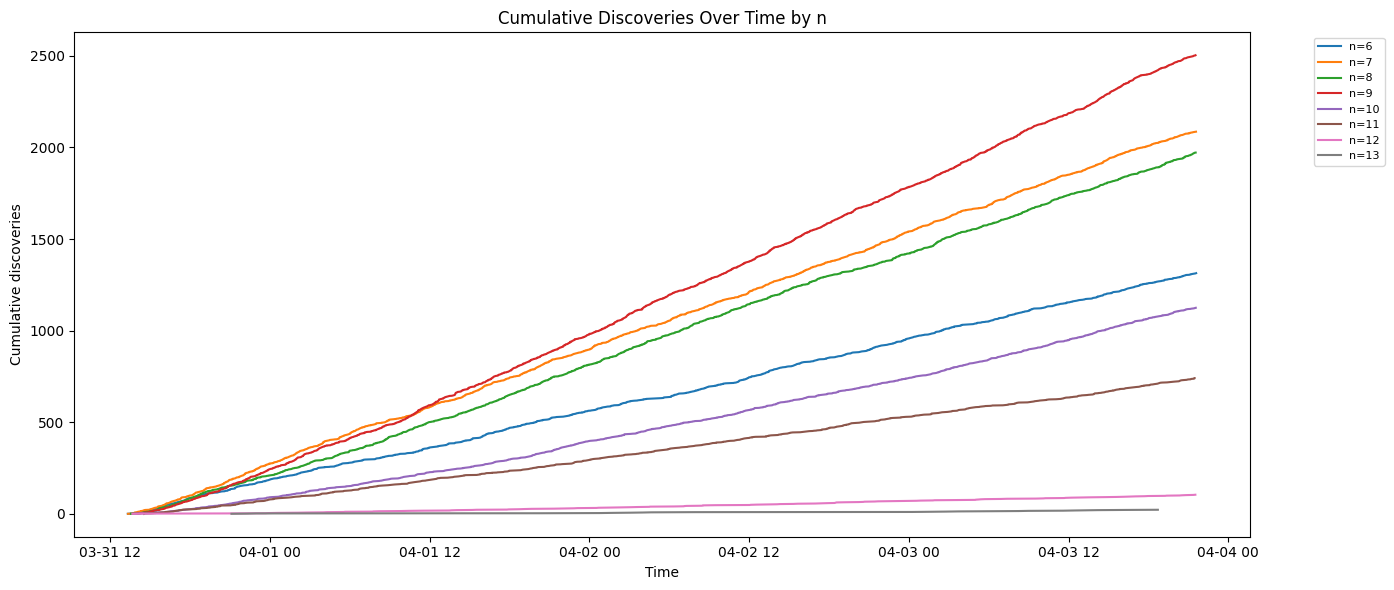

In [37]:
fig, ax = plt.subplots(figsize=(14, 6))

# Cumulative discoveries by n over time
for n in all_ns:
    sub = df[df['n'] == n].sort_values('ts')
    if len(sub) > 0:
        ax.plot(sub['ts'], range(1, len(sub) + 1), label=f'n={n}', linewidth=1.5)

ax.set_xlabel('Time')
ax.set_ylabel('Cumulative discoveries')
ax.set_title('Cumulative Discoveries Over Time by n')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Diversity Gap Analysis

In [9]:
rows = []
for n in all_ns:
    possible = all_exponent_types(n)
    found_types = set(df[df['n'] == n]['exp_type'].unique())
    missing = [t for t in possible if t not in found_types]
    found_counts = df[df['n'] == n].groupby('exp_type').size().to_dict()
    rows.append({
        'n': n,
        'total_possible': len(possible),
        'found': len(possible) - len(missing),
        'missing': len(missing),
        'coverage_%': round(100 * (len(possible) - len(missing)) / len(possible), 1),
        'total_discoveries': len(df[df['n'] == n]),
        'missing_types': missing if missing else 'none',
    })

gap_df = pd.DataFrame(rows)
print("Diversity Gap Analysis:")
print()
print(gap_df.to_string(index=False))

Diversity Gap Analysis:

 n  total_possible  found  missing  coverage_%  total_discoveries                                 missing_types
 6               2      2        0       100.0               1647                                          none
 7               3      3        0       100.0               1217                                          none
 8               3      3        0       100.0               1441                                          none
 9               4      4        0       100.0               1206                                          none
10               4      4        0       100.0                788                                          none
11               5      5        0       100.0                716                                          none
12               5      5        0       100.0                613                                          none
13               6      5        1        83.3                600              